# Pre trained network
![imagen](./img/llustrations-of-transfer-learning-a-neural-network-is-pretrained-on-ImageNet-and.png)

Estas son las arquitecturas de redes neuronales más utilizadas en la comunidad. Para más detalle sobre el funcionamiento de cada red, consultar el [Hands on Machine Learning for Python](https://learning.oreilly.com/library/view/hands-on-machine-learning/9781492032632/ch14.html#cnn_chapter).
* VGG-16
* VGG-19
* Inception V3
* XCeption
* ResNet-50

Las redes se pueden incorporar entrenadas, o sin entrenar.

## ResNet50V2

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from skimage.io import imread
import cv2

from tensorflow.keras.applications.resnet_v2 import ResNet50V2, decode_predictions, preprocess_input

In [2]:
# CODE MODEL
base_model = ResNet50V2(include_top= True, input_shape=(224, 224, 3), weights='imagenet', classifier_activation= 'softmax')

In [3]:
len(base_model.layers)

192

In [4]:
base_model.summary()

Model: "resnet50v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 25,613,800 (97.71 MB)

 Trainable params: 25,568,360 (97.54 MB)

 Non-trainable params: 45,440 (177.50 KB)

Cargamos algunas imagenes desde local, para ver qué tal funciona la red ResNet50V2 ya entrenada.

In [5]:
# CODE READ DATA

import os

def read_data(path):
    X = []
    for file in os.listdir(path):
        image = imread(path + '/' + file)
        smallimage = cv2.resize(image, (224,224))
        print(path + '/' + file)

        X.append(smallimage)
    return np.array(X)


In [6]:
X_test = read_data('img')

#Preprocesar las imagenes tal y como entran en el model
X_test = preprocess_input(X_test)
print(X_test.shape)

img/dog.11857.jpg
img/cat.8037.jpg
img/horse.jpg
img/dog.11856.jpg
img/bear-1.jpg
img/llustrations-of-transfer-learning-a-neural-network-is-pretrained-on-ImageNet-and.png
img/cat.8016.jpg
img/pizza.jpg
img/karate.jpg
(9, 224, 224, 3)


In [7]:
# CODE preds

preds = base_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 661ms/step


In [8]:
len(preds)

9

In [9]:
preds

array([[2.21356076e-11, 5.28719299e-12, 1.83439930e-11, ...,
        6.36439989e-12, 2.48049897e-11, 4.15316670e-11],
       [8.51677981e-08, 1.48219726e-07, 2.96174107e-08, ...,
        6.29417372e-08, 3.85343213e-07, 2.36543292e-06],
       [6.63232356e-07, 4.32088518e-06, 8.08255209e-06, ...,
        1.74185061e-06, 1.03868661e-05, 2.94005440e-05],
       ...,
       [1.97707413e-05, 5.40830697e-05, 1.66412356e-05, ...,
        1.18372036e-05, 1.11987945e-04, 2.58014916e-04],
       [4.66890491e-08, 3.35646064e-07, 8.29790920e-08, ...,
        4.40286300e-07, 4.27221011e-07, 1.87025417e-08],
       [1.00017431e-07, 7.63490025e-05, 2.60810448e-05, ...,
        2.81111988e-06, 5.11688404e-06, 9.27550627e-06]],
      shape=(9, 1000), dtype=float32)

In [10]:
len(preds[0])

1000

In [11]:
decodes = decode_predictions(preds, top=3)

In [12]:
decodes

[[('n02106030', 'collie', np.float32(0.99525714)),
  ('n02105855', 'Shetland_sheepdog', np.float32(0.00474294)),
  ('n12057211', "yellow_lady's_slipper", np.float32(9.142524e-09))],
 [('n02124075', 'Egyptian_cat', np.float32(0.8209837)),
  ('n02127052', 'lynx', np.float32(0.12679492)),
  ('n02123597', 'Siamese_cat', np.float32(0.021530634))],
 [('n02113799', 'standard_poodle', np.float32(0.3245585)),
  ('n02091831', 'Saluki', np.float32(0.30035397)),
  ('n02412080', 'ram', np.float32(0.12327877))],
 [('n02106550', 'Rottweiler', np.float32(0.73290956)),
  ('n02112706', 'Brabancon_griffon', np.float32(0.08508457)),
  ('n02093256', 'Staffordshire_bullterrier', np.float32(0.031059384))],
 [('n02132136', 'brown_bear', np.float32(0.999444)),
  ('n02112137', 'chow', np.float32(0.00054155657)),
  ('n02133161', 'American_black_bear', np.float32(8.780947e-06))],
 [('n06359193', 'web_site', np.float32(0.82318693)),
  ('n03857828', 'oscilloscope', np.float32(0.053272333)),
  ('n04372370', 'switch'

In [13]:
# CODE decode preds
for j in decodes:
    print('####################')
    for i,decode in enumerate(j):
        print("Predicted:\n", decode[1], decode[2])

####################
Predicted:
 collie 0.99525714
Predicted:
 Shetland_sheepdog 0.00474294
Predicted:
 yellow_lady's_slipper 9.142524e-09
####################
Predicted:
 Egyptian_cat 0.8209837
Predicted:
 lynx 0.12679492
Predicted:
 Siamese_cat 0.021530634
####################
Predicted:
 standard_poodle 0.3245585
Predicted:
 Saluki 0.30035397
Predicted:
 ram 0.12327877
####################
Predicted:
 Rottweiler 0.73290956
Predicted:
 Brabancon_griffon 0.08508457
Predicted:
 Staffordshire_bullterrier 0.031059384
####################
Predicted:
 brown_bear 0.999444
Predicted:
 chow 0.00054155657
Predicted:
 American_black_bear 8.780947e-06
####################
Predicted:
 web_site 0.82318693
Predicted:
 oscilloscope 0.053272333
Predicted:
 switch 0.033840902
####################
Predicted:
 Egyptian_cat 0.64985037
Predicted:
 Siamese_cat 0.16787326
Predicted:
 tiger_cat 0.06044936
####################
Predicted:
 pizza 0.9971305
Predicted:
 bagel 0.0011670311
Predicted:
 potpie 0.001

## VGG16
En este caso vamos a importar la red VGG16, que utilizaremos como red preentrenada y completaremos con una fully connected layer. 

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split

IM_SIZE=32

TRAIN_PATH = '/Users/fgoiri/Documents/Documentos_Fatima/dogs_cats/train/'
filenames = os.listdir(TRAIN_PATH)
categories = []
for filename in filenames:
    category = filename.split('.')[0]
    categories.append(category)
    
df = pd.DataFrame({
    'filenames': filenames,
    'category': categories
})

train_df, validate_df = train_test_split(df,
                                         test_size=0.20,
                                         random_state=42)

train_df = train_df.reset_index(drop=True)
validate_df = validate_df.reset_index(drop=True)

In [15]:
train_df.head()

,filenames,category
0,cat.1088.jpg,cat
1,cat.1169.jpg,cat
2,cat.91.jpg,cat
3,dog.10489.jpg,dog
4,cat.485.jpg,cat


In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# Add our data-augmentation parameters to ImageDataGenerator
train_datagen = ImageDataGenerator(rescale = 1./255.,
                                   rotation_range = 40,
                                   width_shift_range = 0.2,
                                   height_shift_range = 0.2,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

# Note that the validation data should not be augmented!
validation_datagen = ImageDataGenerator(rescale = 1.0/255. )

In [17]:
# Flow training images in batches of 20 using train_datagen generator
train_generator = train_datagen.flow_from_dataframe(train_df,
                                                    TRAIN_PATH,
                                                    x_col='filenames',
                                                    y_col='category',
                                                    batch_size = 20,
                                                    class_mode = 'binary',
                                                    target_size = (32, 32))

# Flow validation images in batches of 20 using test_datagen generator
validation_generator = validation_datagen.flow_from_dataframe(validate_df,
                                                              TRAIN_PATH,
                                                              x_col='filenames',
                                                              y_col='category',
                                                              batch_size = 20,
                                                              class_mode = 'binary',
                                                              target_size = (IM_SIZE, IM_SIZE))

Found 5260 validated image filenames belonging to 2 classes.
Found 1316 validated image filenames belonging to 2 classes.


In [18]:
from tensorflow.keras.applications.vgg16 import VGG16

# CODE model
base_model = VGG16(input_shape=(IM_SIZE,IM_SIZE,3),
                    include_top=False, # no me incluyas el final
                    weights = 'imagenet'
                )
# Solo me quedo con la parte convolucional

In [19]:
len(base_model.layers)

19

In [20]:
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:

##### FULLY CONNECTED LAYER #####
# Flatten the output layer to 1 dimension
x = layers.Flatten()(base_model.output)

# Add a fully connected layer with 512 hidden units and ReLU activation
x = layers.Dense(512, activation='relu')(x)

# Add a dropout rate of 0.25
x = layers.Dropout(0.25)(x)

# Add a final sigmoid layer for classification
x = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.models.Model(base_model.input, x)
    
model.compile(optimizer = 'adam', loss = 'binary_crossentropy',metrics = ['acc'])

In [22]:
len(model.layers)

23

In [23]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977,857 (57.14 MB)

 Trainable params: 14,977,857 (57.14 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
vgghist = model.fit(train_generator,
                   validation_data = validation_generator,
                   batch_size = 128,
                   epochs = 5)

Epoch 1/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 44s 161ms/step - acc: 0.5981 - loss: 0.7090 - val_acc: 0.4195 - val_loss: 0.6991
Epoch 2/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 43s 162ms/step - acc: 0.6118 - loss: 0.6724 - val_acc: 0.6064 - val_loss: 0.6820
Epoch 3/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 41s 156ms/step - acc: 0.6416 - loss: 0.6503 - val_acc: 0.6451 - val_loss: 0.6681
Epoch 4/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 40s 151ms/step - acc: 0.6219 - loss: 0.6743 - val_acc: 0.5935 - val_loss: 0.6831
Epoch 5/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 40s 153ms/step - acc: 0.6219 - loss: 0.6736 - val_acc: 0.5935 - val_loss: 0.6921


<Axes: >

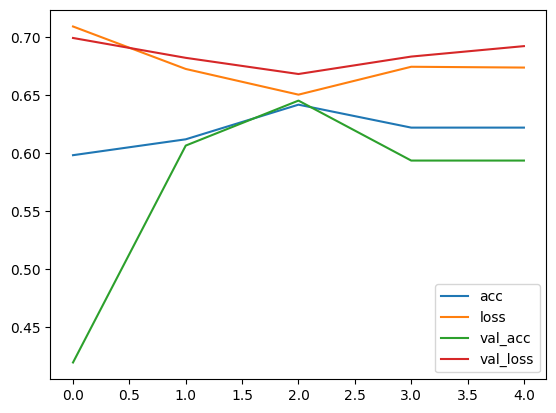

In [25]:
pd.DataFrame(vgghist.history).plot()

## ResNet50V2 sin últimas capas y sin pesos preentrenados

In [26]:
IM_SIZE=32

base_model = ResNet50V2(input_shape = (32, 32, 3),
                       include_top = None,
                       weights = None,
                       classifier_activation= "softmax")


train_generator = train_datagen.flow_from_dataframe(train_df,
                                                    TRAIN_PATH,
                                                    x_col='filenames',
                                                    y_col='category',
                                                    batch_size = 20,
                                                    class_mode = 'binary',
                                                    target_size = (32, 32))

# Flow validation images in batches of 20 using test_datagen generator
validation_generator = validation_datagen.flow_from_dataframe(validate_df,
                                                              TRAIN_PATH,
                                                              x_col='filenames',
                                                              y_col='category',
                                                              batch_size = 20,
                                                              class_mode = 'binary',
                                                              target_size = (32, 32))

Found 5260 validated image filenames belonging to 2 classes.
Found 1316 validated image filenames belonging to 2 classes.


In [27]:
len(base_model.layers)

190

In [28]:
base_model.summary()

Model: "resnet50v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 38, 38, 3) │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 16, 16,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 18, 18,    │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 8, 8, 64)  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 8, 8, 64)  │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 8, 8, 64)  │          0 │ conv2_block1_pre… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 8, 64)  │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 10, 10,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 8, 64)  │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 8, 8, 256) │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 8, 8, 256) │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 8, 8, 256) │          0 │ conv2_block1_0_c

 Total params: 23,564,800 (89.89 MB)

 Trainable params: 23,519,360 (89.72 MB)

 Non-trainable params: 45,440 (177.50 KB)

In [31]:
x = layers.Flatten()(base_model.output)

# Add a fully connected layer with 512 hidden units and ReLU activation
x = layers.Dense(512, activation='relu')(x)

# Add a dropout rate of 0.5
x = layers.Dropout(0.1)(x)

# Add a final sigmoid layer for classification
x = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.models.Model(base_model.input, x)
    
model.compile(optimizer = 'adam', loss = 'binary_crossentropy',metrics = ['acc'])

In [32]:
len(model.layers)

194

In [33]:
model.fit(train_generator,
         validation_data = validation_generator,
         steps_per_epoch = 100,
         epochs = 20)

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 33s 233ms/step - acc: 0.5675 - loss: 0.7997 - val_acc: 0.5935 - val_loss: 0.6775
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 231ms/step - acc: 0.6205 - loss: 0.6666 - val_acc: 0.5935 - val_loss: 0.6746
Epoch 3/20
 63/100 ━━━━━━━━━━━━━━━━━━━━ 8s 222ms/step - acc: 0.6339 - loss: 0.6600

/Users/fgoiri/miniconda3/envs/bootcamp2/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 149ms/step - acc: 0.6246 - loss: 0.6585 - val_acc: 0.5935 - val_loss: 0.6760
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 234ms/step - acc: 0.6295 - loss: 0.6518 - val_acc: 0.5935 - val_loss: 0.7241
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 231ms/step - acc: 0.6345 - loss: 0.6479 - val_acc: 0.6231 - val_loss: 0.6466
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 147ms/step - acc: 0.6175 - loss: 0.6488 - val_acc: 0.6284 - val_loss: 0.6719
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 230ms/step - acc: 0.6550 - loss: 0.6304 - val_acc: 0.5312 - val_loss: 0.7668
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 230ms/step - acc: 0.6550 - loss: 0.6301 - val_acc: 0.5623 - val_loss: 0.7282
Epoch 9/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 148ms/step - acc: 0.6532 - loss: 0.6140 - val_acc: 0.4863 - val_loss: 0.8374
Epoch 10/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 229ms/step - acc: 0.6635 - loss: 0.6293 - val_acc: 0.5357 - val_loss: 0.9447
Epoch 11/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2

In [34]:
test_datagen = ImageDataGenerator(rescale=1./255)  # Escala los píxeles entre 0 y 1

In [ ]:
# # Flow validation images in batches of 20 using test_datagen generator
# test_generator = test_datagen.flow_from_dataframe(test_df,
#                                                              TRAIN_PATH,
#                                                              x_col='filenames',
#                                                              y_col='category',
#                                                              batch_size = 20,
#                                                              class_mode = 'binary',
#                                                              target_size = (224, 224))

In [ ]:
# loss, accuracy = model.evaluate(validation_generator, verbose=1)